In [ ]:
!nvidia-smi

Sat Mar 29 02:08:53 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLO11 via Ultralytics

In [ ]:
%pip install "ultralytics<=8.3.40" supervision roboflow
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.4/112.6 GB disk)


## Fine-tune our YOLO11 model on custom PKLOT dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir -p /content/datasets

!unzip -o /content/drive/MyDrive/PKLot.v2-640.yolov11.zip -d /content/datasets/pk_lot_dataset

DATASET_PATH="/content/datasets/pk_lot_dataset"

!ls {DATASET_PATH}

!yolo task=detect mode=train model=yolo11s.pt data={DATASET_PATH}/data.yaml epochs=10 imgsz=640 plots=True project=/content/runs/detect name=train_exp

!ls -la /content/runs/detect/train_exp

!mkdir -p /content/drive/MyDrive/yolo_results
!cp -r /content/runs/detect/train_exp /content/drive/MyDrive/yolo_results/


Streaming output truncated to the last 5000 lines.
 extracting: /content/datasets/pk_lot_dataset/valid/images/2012-09-16_06_22_55_jpg.rf.ee4c08bfcc20248a536d12aa09def8b7.jpg  
 extracting: /content/datasets/pk_lot_dataset/valid/images/2012-09-16_06_42_56_jpg.rf.d501e60c288100776e11466c3d65884a.jpg  
 extracting: /content/datasets/pk_lot_dataset/valid/images/2012-09-16_07_27_57_jpg.rf.191717707b59b756b12b994598f437bd.jpg  
 extracting: /content/datasets/pk_lot_dataset/valid/images/2012-09-16_07_37_58_jpg.rf.0b878e29417eec0557a97af0cda550fd.jpg  
 extracting: /content/datasets/pk_lot_dataset/valid/images/2012-09-16_07_52_58_jpg.rf.e884103dc5246d4e9f0c616b760192ab.jpg  
 extracting: /content/datasets/pk_lot_dataset/valid/images/2012-09-16_08_07_59_jpg.rf.d3fcf0a4f874a8b2e1bfc8e390f1600f.jpg  
 extracting: /content/datasets/pk_lot_dataset/valid/images/2012-09-16_08_12_59_jpg.rf.1c7bb2d0244981621193e543be61e78d.jpg  
 extracting: /content/datasets/pk_lot_dataset/valid/images/2012-09-16_08_2

## Custom Training

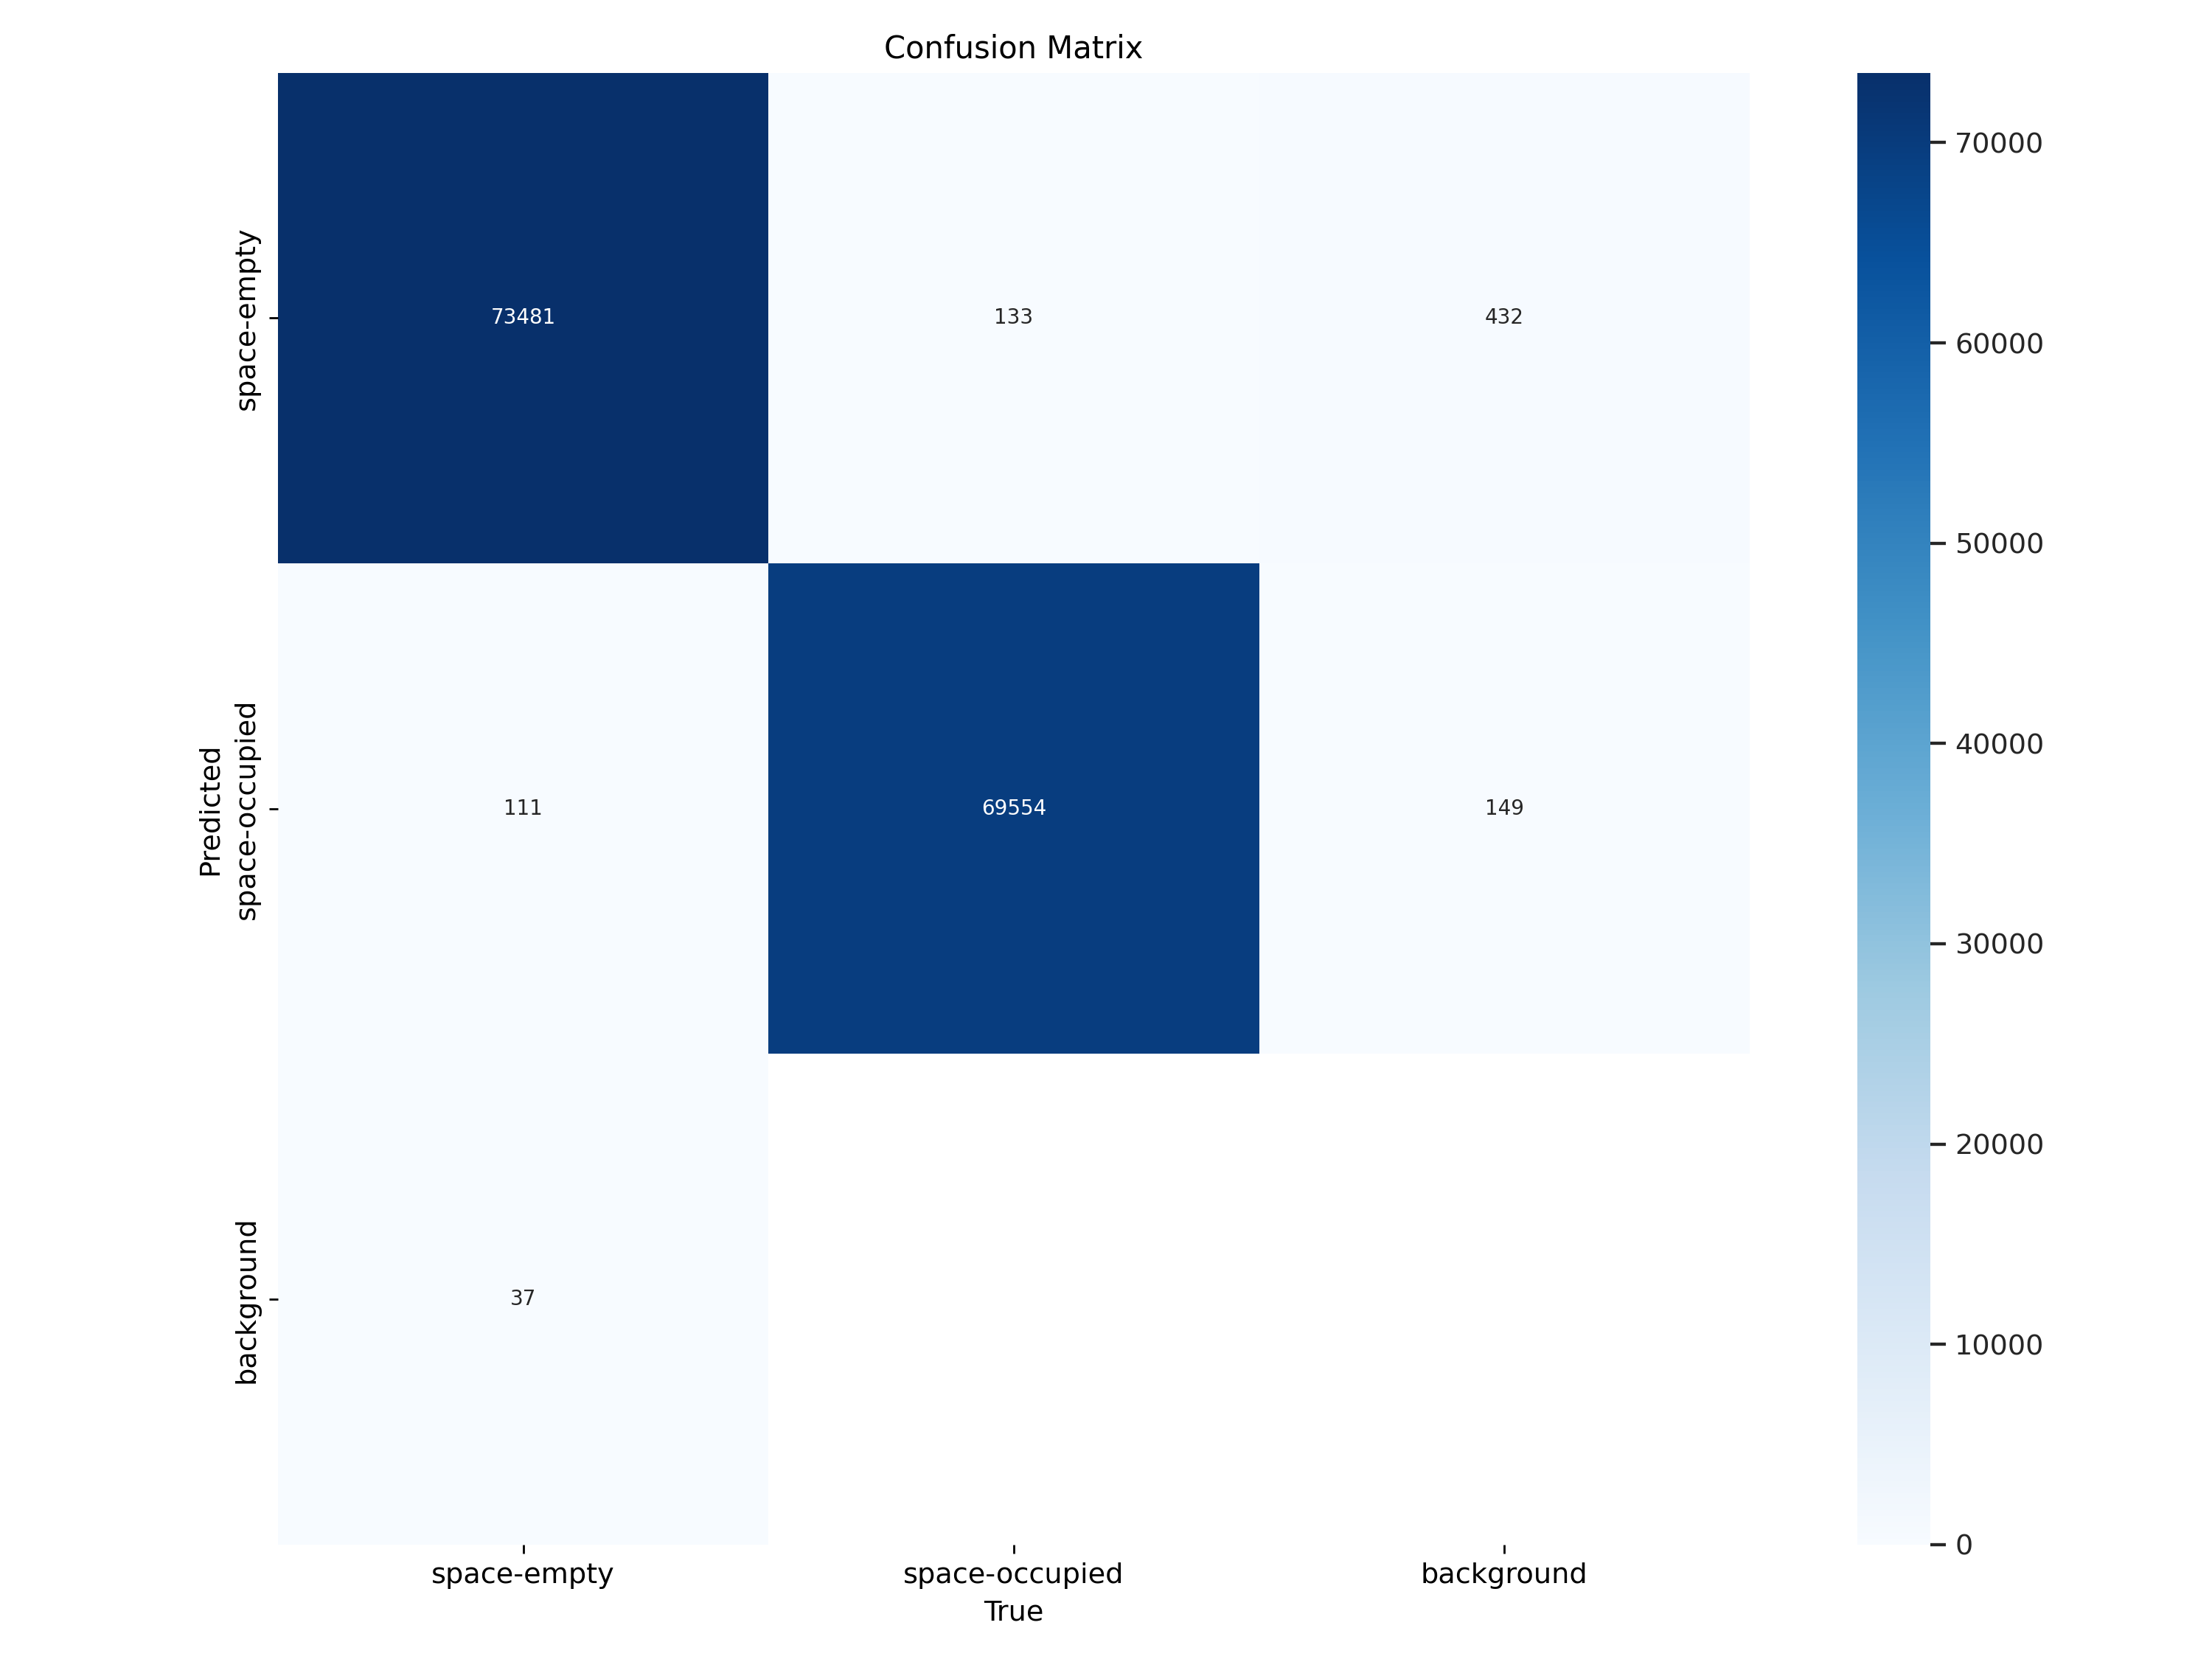

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train_exp/confusion_matrix.png', width=600)

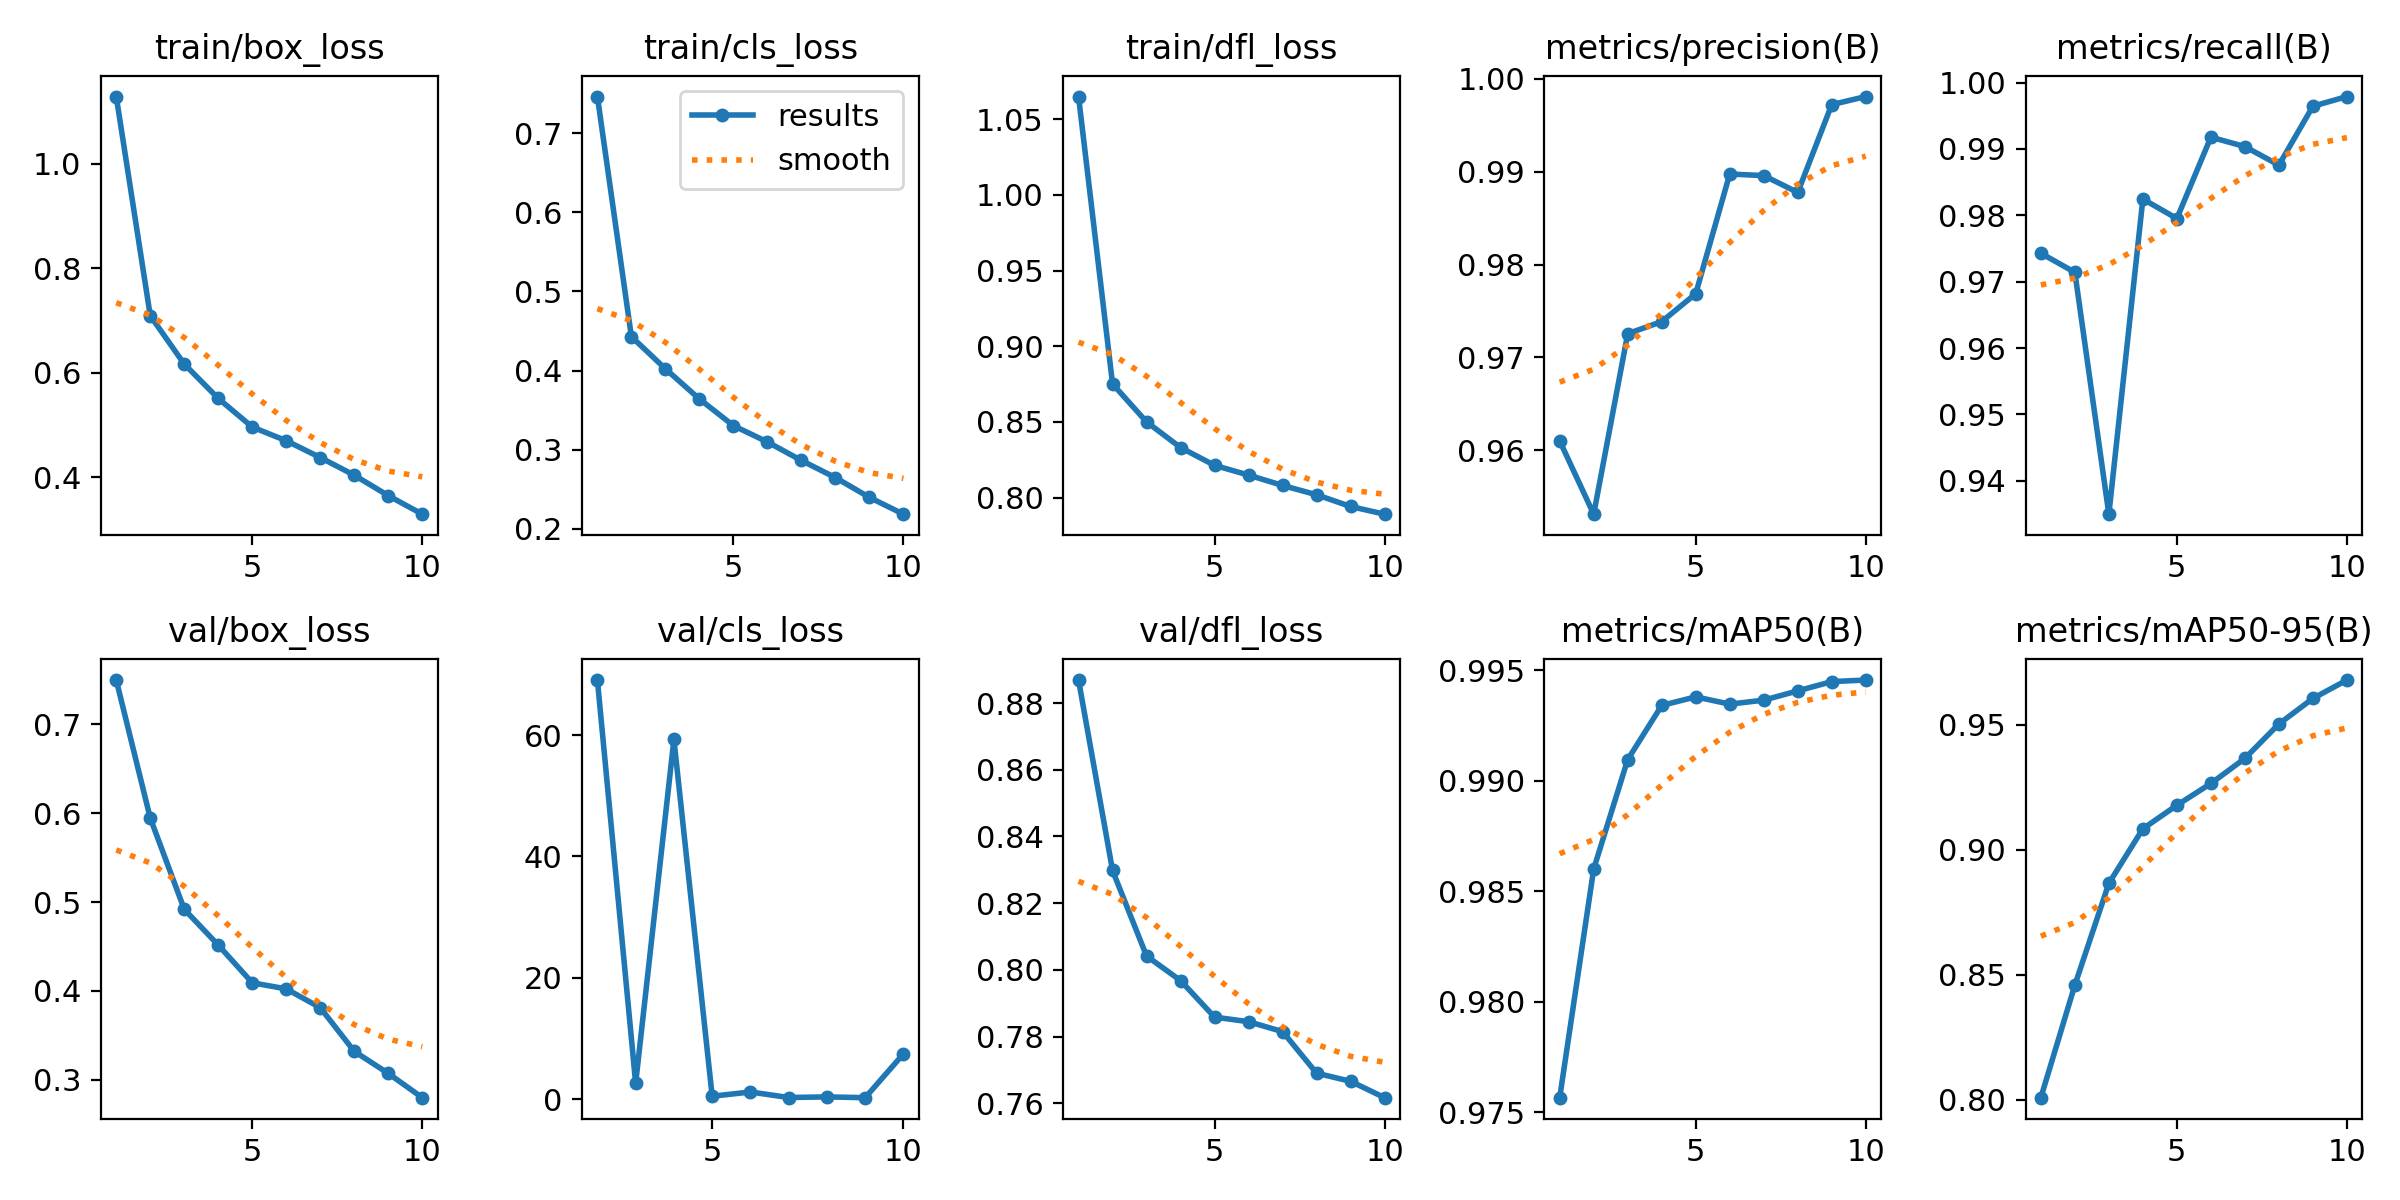

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train_exp/results.png', width=600)

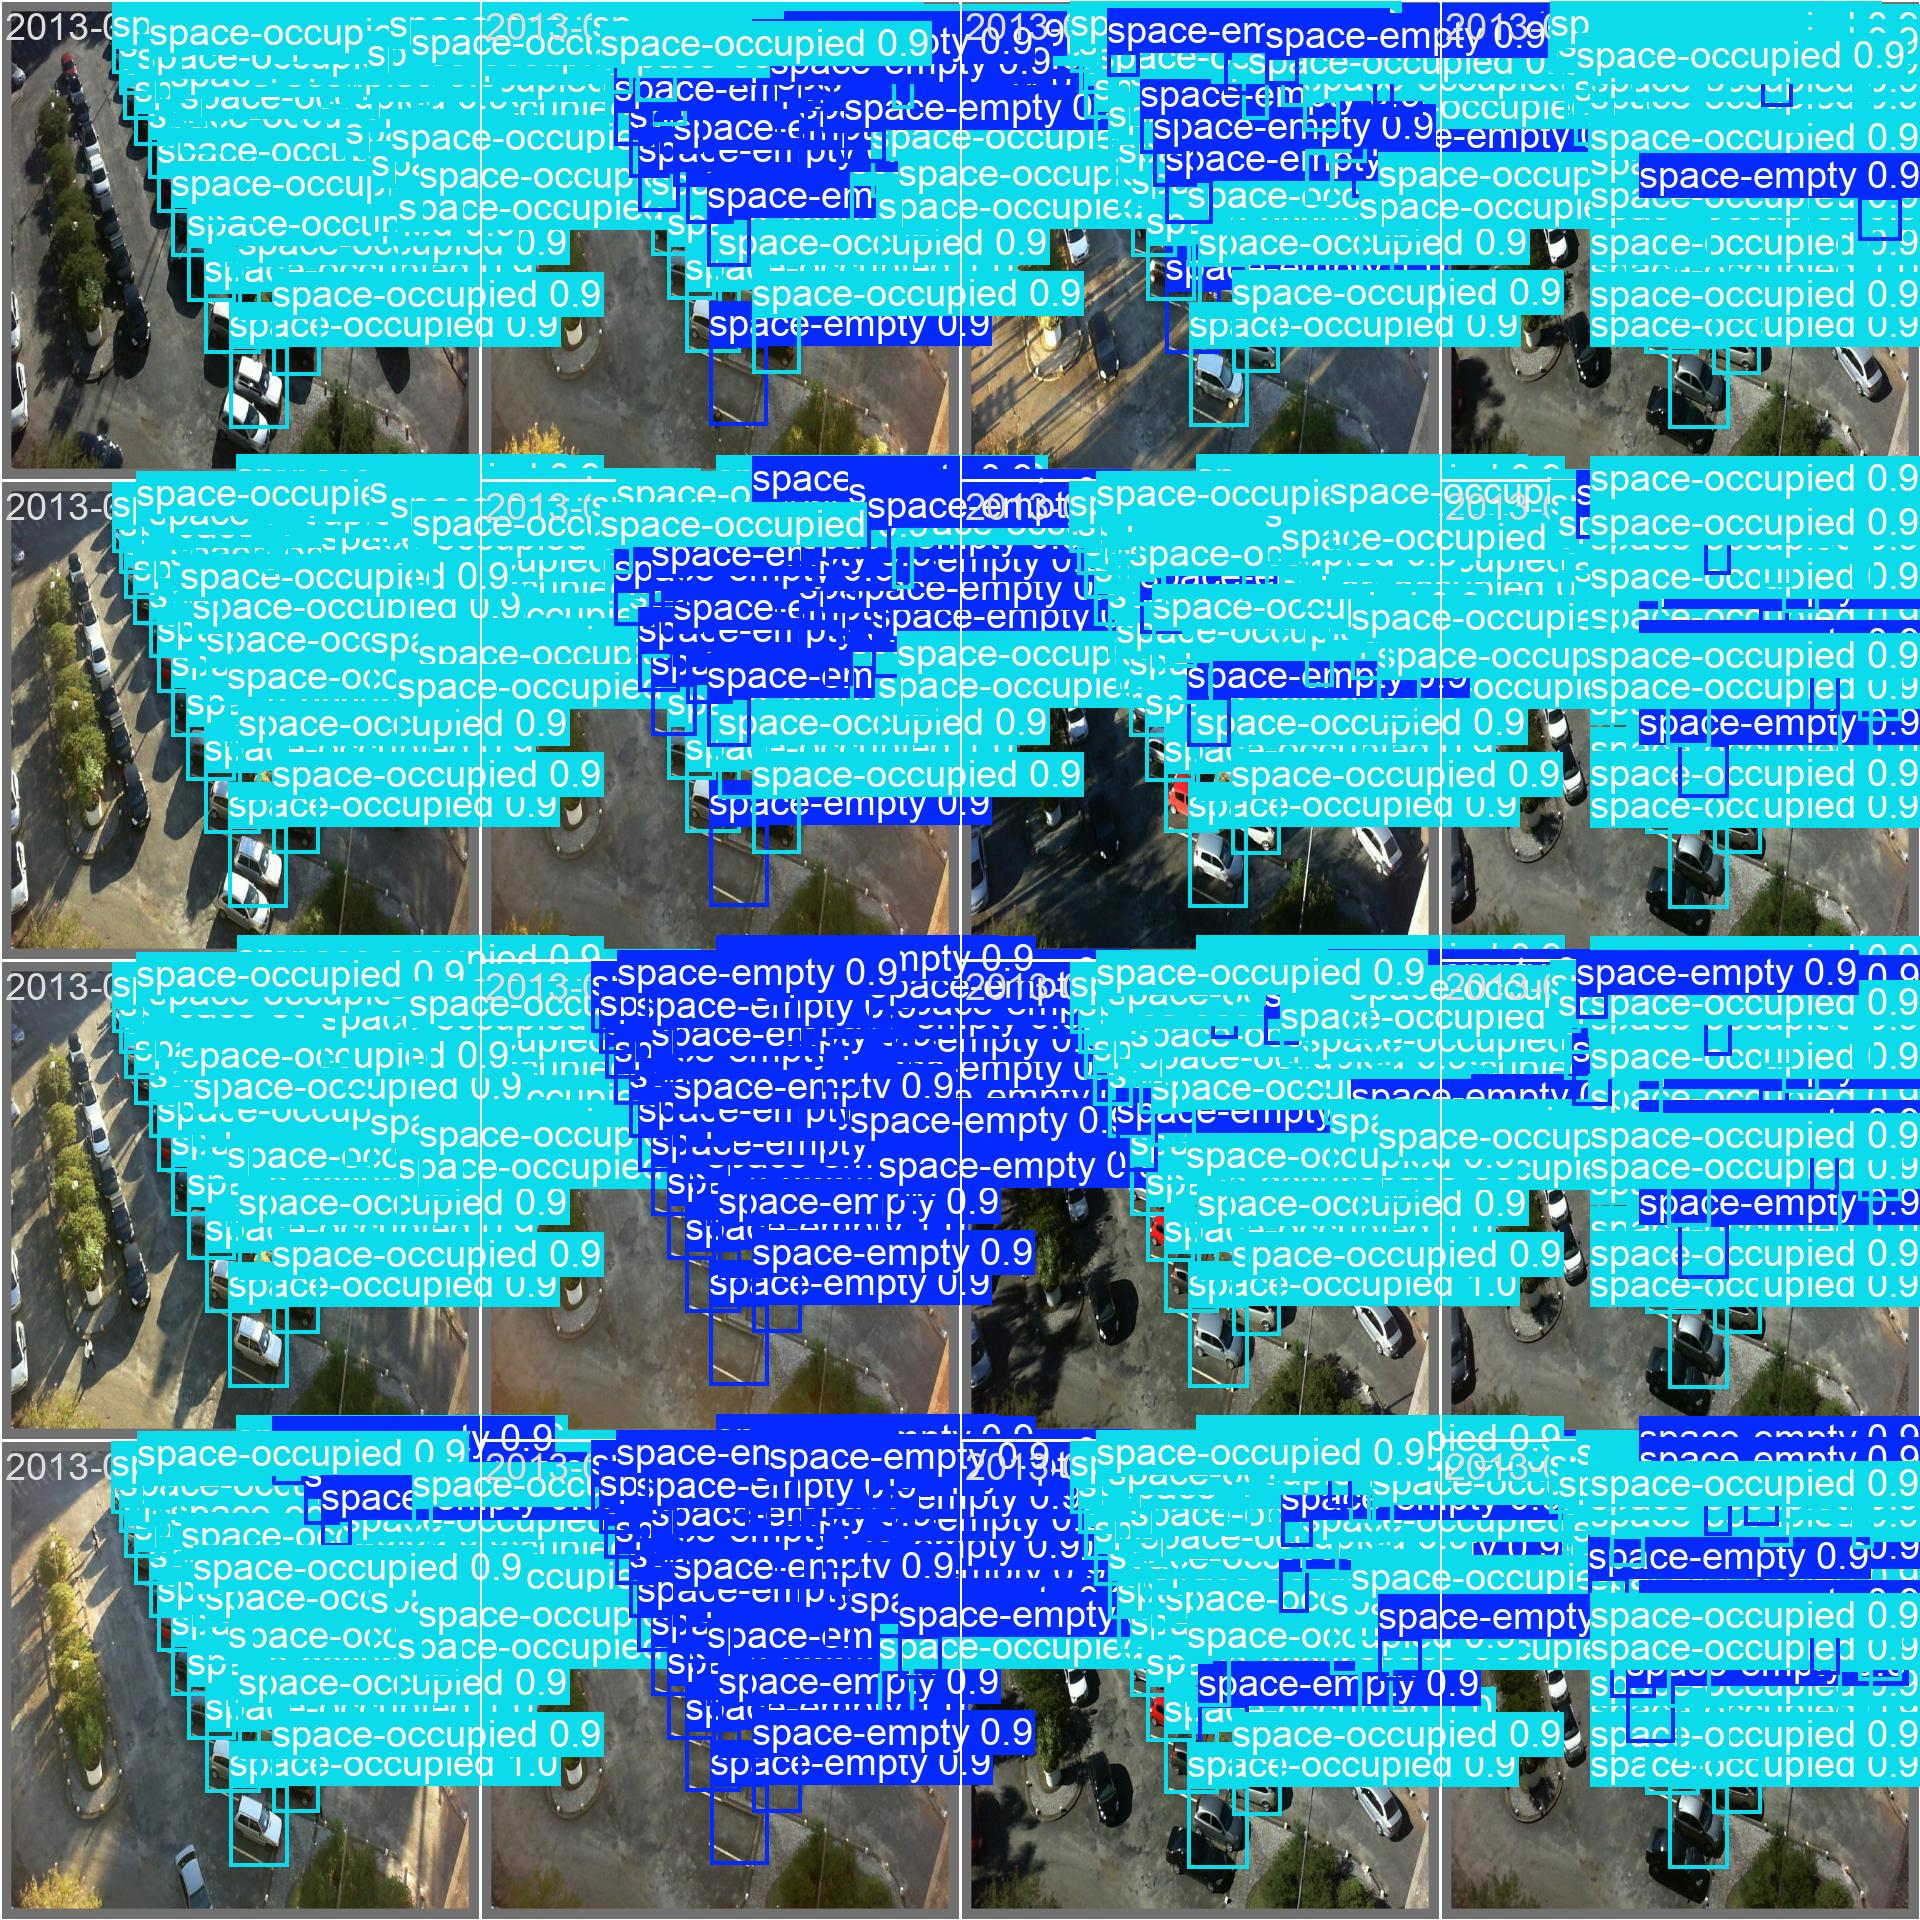

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train_exp/val_batch0_pred.jpg', width=600)

## Validate fine-tuned model

In [ ]:
!yolo task=detect mode=val model=/content/runs/detect/train_exp/weights/best.pt data=/content/datasets/pk_lot_dataset/data.yaml

Ultralytics 8.3.40 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 238 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
val: Scanning /content/datasets/pk_lot_dataset/valid/labels.cache... 2483 images, 59 backgrounds, 0 corrupt: 100% 2483/2483 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 156/156 [01:06<00:00,  2.33it/s]
                   all       2483     143316      0.998      0.998      0.995      0.971
           space-empty       2062      73629      0.997      0.998      0.995      0.975
        space-occupied       1967      69687      0.999      0.998      0.994      0.967
Speed: 0.4ms preprocess, 9.0ms inference, 0.0ms loss, 1.1ms postprocess per image
Results saved to runs/detect/val2
💡 Learn more at https://docs.ultralytics.com/modes/val


In [ ]:
!cp -r /content/runs/detect/predict /content/drive/MyDrive/yolo_results/

In [ ]:
!cp -r /content/runs/detect/val /content/drive/MyDrive/yolo_results/

In [ ]:
!cp -r /content/runs/detect/val2 /content/drive/MyDrive/yolo_results/

## Inference with custom model

In [ ]:
!yolo task=detect mode=predict model=/content/runs/detect/train_exp/weights/best.pt conf=0.25 source=/content/datasets/pk_lot_dataset/test/images save=True

Ultralytics 8.3.40 🚀 Python-3.11.11 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 238 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs

image 1/1242 /content/datasets/pk_lot_dataset/test/images/2012-09-11_15_53_00_jpg.rf.8282544a640a23df05bd245a9210e663.jpg: 640x640 28 space-emptys, 72 space-occupieds, 15.6ms
image 2/1242 /content/datasets/pk_lot_dataset/test/images/2012-09-11_16_48_36_jpg.rf.4ecc8c87c61680ccc73edc218a2c8d7d.jpg: 640x640 25 space-emptys, 77 space-occupieds, 15.6ms
image 3/1242 /content/datasets/pk_lot_dataset/test/images/2012-09-12_06_36_36_jpg.rf.08869047c7e9f62f5ce9334546b52958.jpg: 640x640 100 space-emptys, 15.6ms
image 4/1242 /content/datasets/pk_lot_dataset/test/images/2012-09-12_08_15_53_jpg.rf.025635f821fe24c12ab497efbfd3d35c.jpg: 640x640 7 space-emptys, 93 space-occupieds, 15.6ms
image 5/1242 /content/datasets/pk_lot_dataset/test/images/2012-09-12_09_18_46_jpg.rf.d95bc1a314fb384813111f94c25b4ef3.jpg: 640x640 5 space-emptys, 95 spa

In [ ]:
!cp -r /content/runs/detect/predict2 /content/drive/MyDrive/yolo_results/

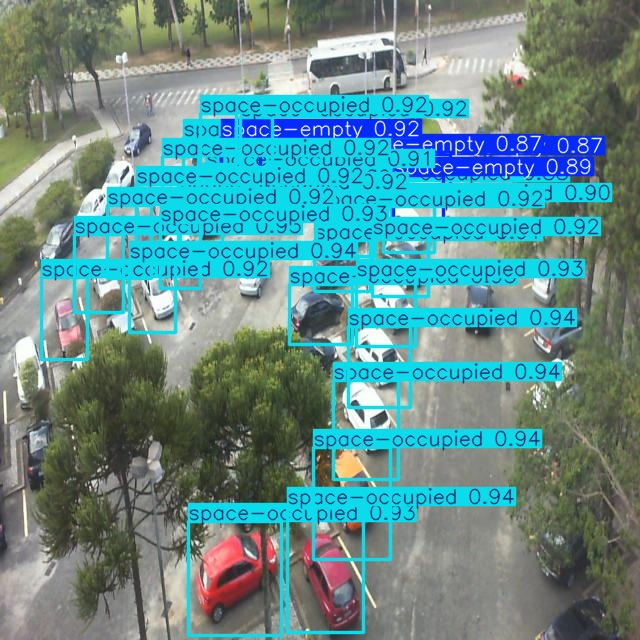

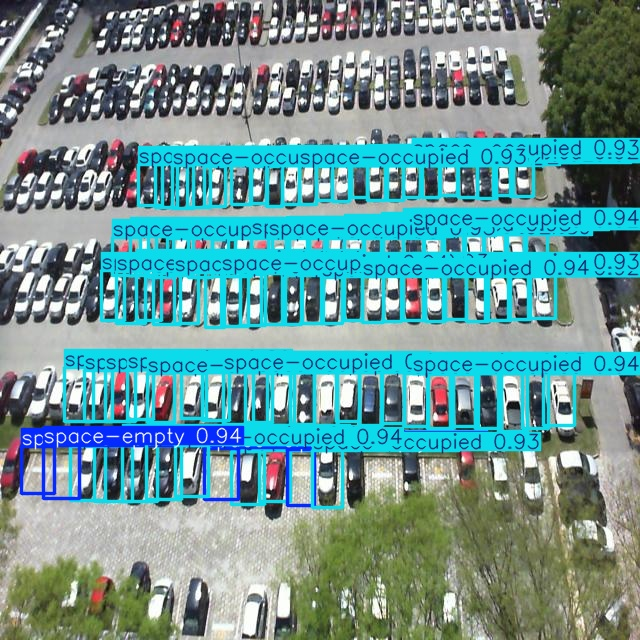

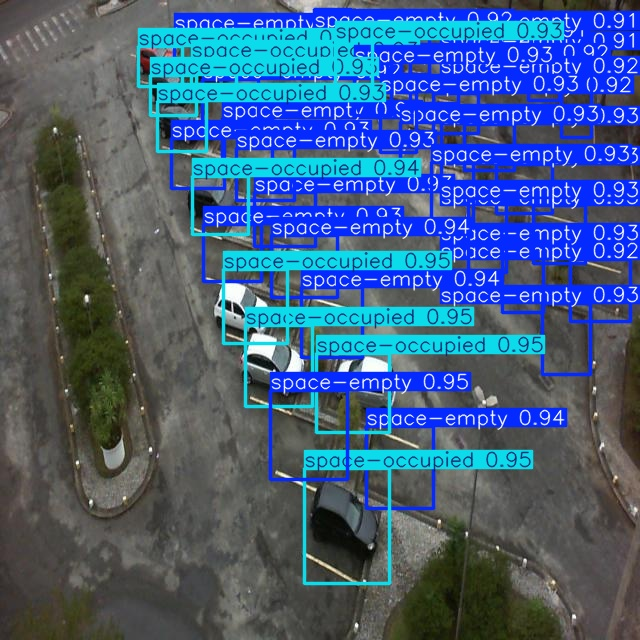

In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

List of References
1. Official Yolov11 documentation : https://docs.ultralytics.com/models/yolo11/
2. Medium : https://medium.com/@estebanuri/training-yolov11-object-detector-on-a-custom-dataset-39bba09530ff
3. Roboflow : https://roboflow.com/
4. Albumentations : https://arxiv.org/abs/1809.06839
